## Circos plots of VFC 1, 2, and 4 genomes, including SNP, pN/pS, DGR, and gene annotations
Genomes were annotated using:
- pharokka for functional annotation
- DGRscan to identify diversity generating retroelements (DGRs)
- a custom pipeline using LoFreq to call SNPs, classify them as synonymous or nonsynonymous, and compute gene-level pN/pS
- DefenseFinder to identify defense and anti-defense systems

In [1]:
import pandas as pd
import numpy as np

# SNPs

df_snp = pd.read_csv('../data/genome_annotations/SPMP_vcf_annotated.tsv', sep='\t')

# gene-level pN/pS

df_pnps = pd.read_csv('../data/Supplementary_Data_10_pN-pS_analysis.tsv', sep='\t', usecols=['gene','CHROM','sample_id','pNpS'])
df_g = pd.read_csv('../data/Supplementary_Data_4_gene_annotations_of_SPMP_and_reference_vOTUs.tsv', sep='\t', usecols=['gene','start','end'])
df_pnps = df_pnps.merge(df_g, on='gene', how='left')

# DGRs

df_dgr = pd.read_excel('../data/Supplementary_Data_9_DGR_defense_anti-defense_and_AMG_annotations.xlsx', sheet_name='DGRs', usecols=['votu_id','template_coordinates','variable_coordinates'])

Prepare Circos plots

In [2]:
from pycirclize.parser import Genbank
from pycirclize import Circos
from Bio.SeqFeature import SeqFeature, FeatureLocation
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

function_colors = {
    "DNA, RNA and nucleotide metabolism": "orange",        # genome replication/metabolism
    "transcription regulation": "tan",                     # regulation
    "integration and excision": "purple",                  # integration/excision, temperate phage functions
    "moron, auxiliary metabolic gene and host takeover": "pink",  # accessory/metabolic/host takeover genes
    "head and packaging": "steelblue",                     # structural: capsid
    "connector": "lightblue",                              # structural: connector
    "tail": "green",                                       # structural: tail
    "lysis": "lightgreen",                                 # lysis
    "other": "gray",                                       # miscellaneous
    "unknown function": "lightgray"                        # unknown
}

pnps_colors = {
    "<0.5": "#f0f0f0",   # very light grey
    "0.5-1": "#ffffcc",  # very light yellow
    "1-1.5": "#ffe066",  # pale yellow-orange
    "1.5-2": "#ffb84d",  # light orange
    ">2": "#ff9933"      # medium orange
}

def get_pnps_color(p, pnps_colors):
    if p < 0.5:
        return pnps_colors["<0.5"]
    elif p < 1:
        return pnps_colors["0.5-1"]
    elif p < 1.5:
        return pnps_colors["1-1.5"]
    elif p < 2:
        return pnps_colors["1.5-2"]
    else:
        return pnps_colors[">2"]

dgr_colors = {
    "template_coordinates": "green",
    "variable_coordinates": "brown"
}

snp_colors = {
    "Syn": "blue",        # synonymous mutations
    "Non-syn": "red"      # non-synonymous mutations
}

def format_snp_label(label):
    return "synonymous" if label == "Syn" else "nonsynonymous" if label == "Non-syn" else "others"

### Fig. 3F: TLL62_41__full_1 (VFC 2)

In [3]:
v = 'TLL62_41__full_1'
s = 'TLL62'

gbkfile = f'../data/genome_annotations//{v}-pharokka.gbk'
df_depth = pd.read_csv(f'../data/genome_annotations/{v}-{s}-depth.tsv', sep='\t')
df_snp_v = df_snp[(df_snp.CHROM == v) & (df_snp.sample_id == s)]
df_pnps_v = df_pnps[(df_pnps.CHROM == v) & (df_pnps.sample_id == s)].copy()
df_pnps_v[['start','end']] = df_pnps_v[['start','end']].astype(int)
df_dgr_v = df_dgr[df_dgr.votu_id == v]

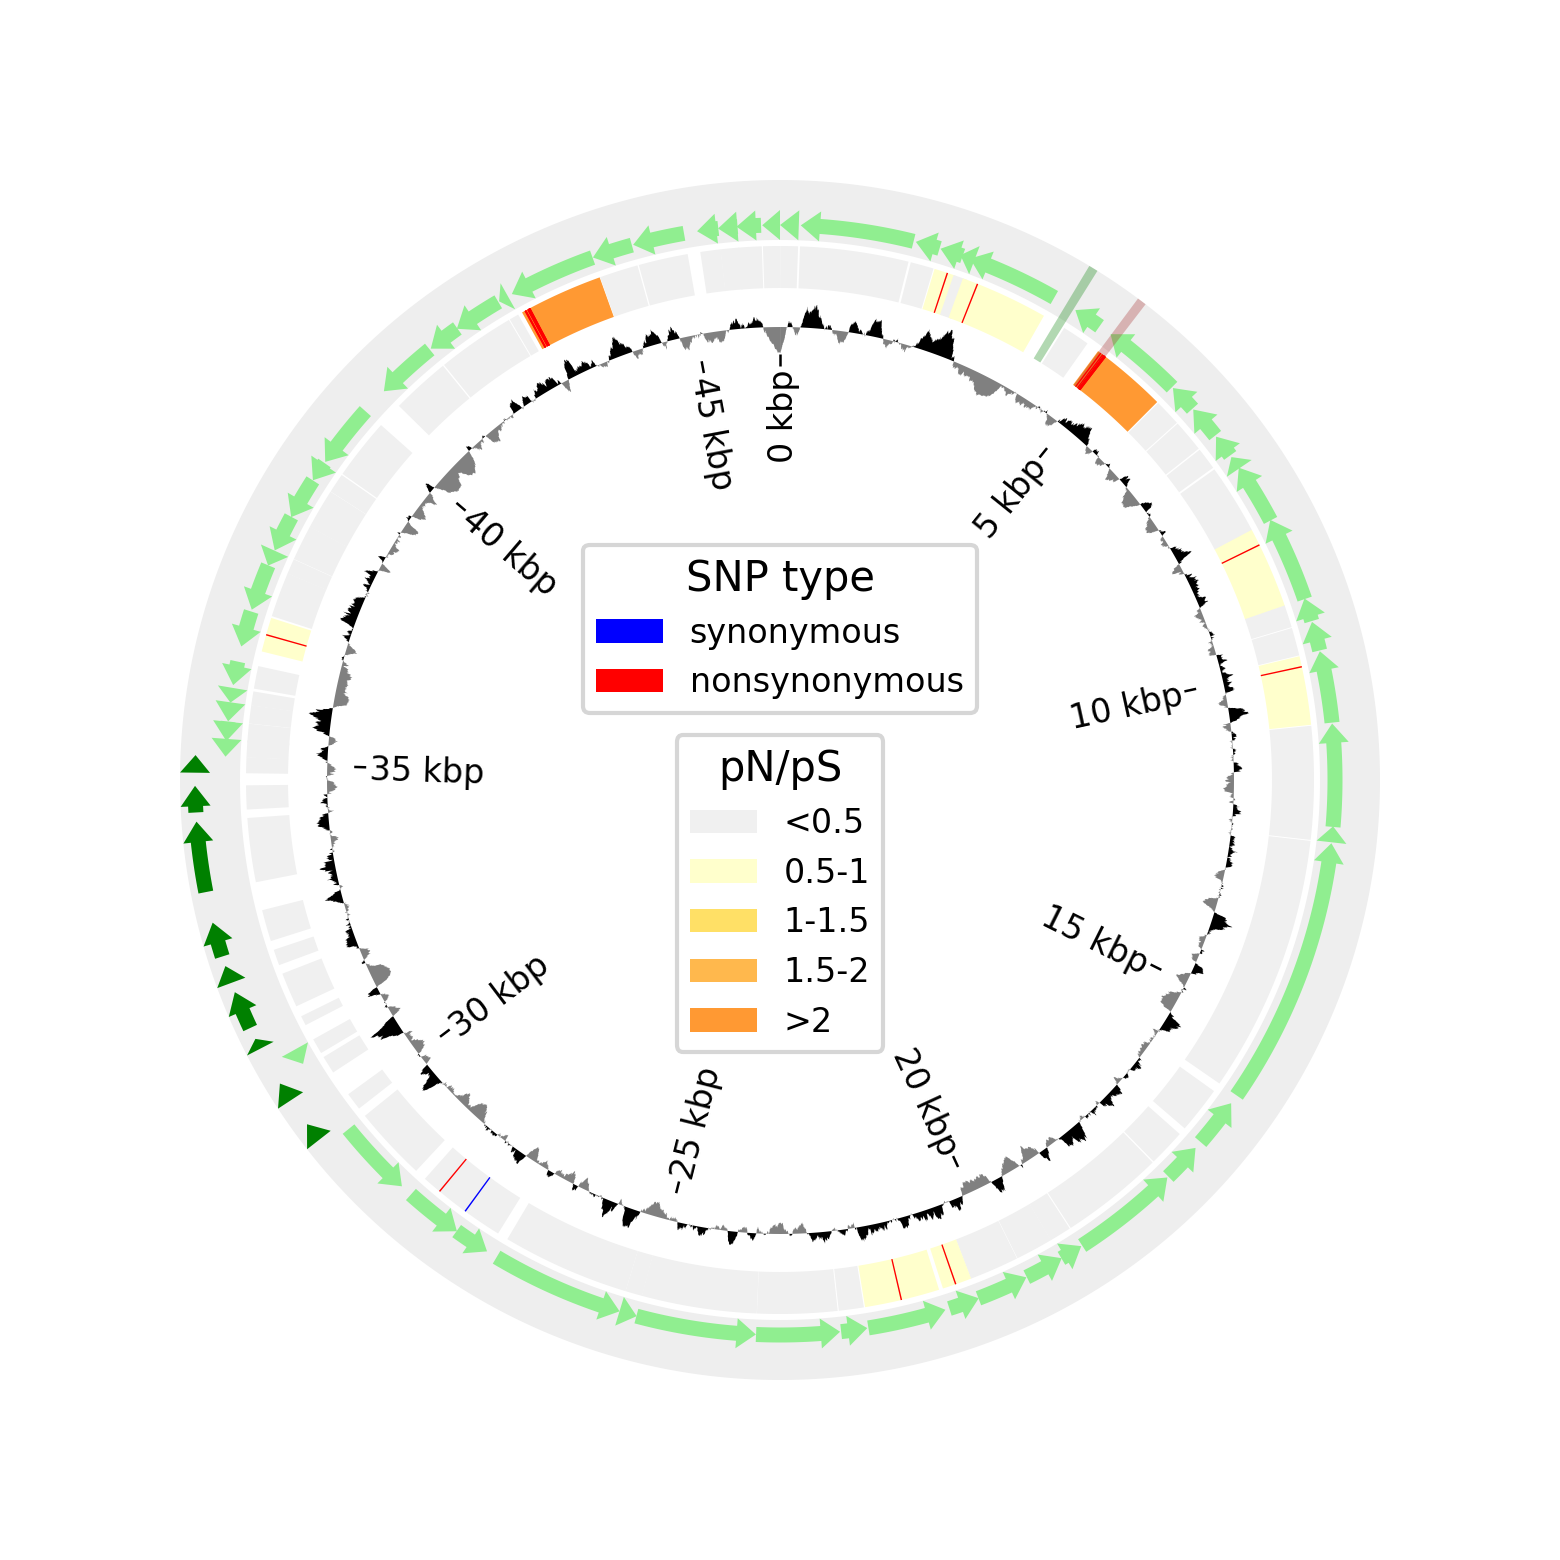

In [4]:
# ---------------------------
# Initialize Circos plot
# ---------------------------
gbk = Genbank(gbkfile)

seqid2size = gbk.get_seqid2size() # chromosome lengths
space = 0 if len(seqid2size) == 1 else 2 # space between chromosomes
circos = Circos(sectors=seqid2size, space=space)

# ---------------------------
# CDS track
# ---------------------------
seqid2features = gbk.get_seqid2features(feature_type="CDS")

for sector in circos.sectors:
    cds_track = sector.add_track((90, 100))
    cds_track.axis(fc="#EEEEEE", ec="none")

    features = seqid2features[sector.name]

    for feature in features:
        start, end = int(feature.location.start), int(feature.location.end)
        label = feature.qualifiers.get("product", [""])[0]
        color = "green" if feature.location.strand == 1 else "lightgreen"

        # Forward/reverse arrows
        if feature.location.strand == 1:
            cds_track.genomic_features(feature,
                                       plotstyle="arrow",
                                       r_lim=(95, 100),
                                       fc=color)
        else:
            cds_track.genomic_features(feature,
                                       plotstyle="arrow",
                                       r_lim=(90, 95),
                                       fc=color)

# ---------------------------
# Coverage skew track
# ---------------------------
cov_track = sector.add_track((71, 81), r_pad_ratio=0.05) # with pN/pS track

# Create coverage table for all positions in genome
all_positions = pd.DataFrame({'POS': range(1, seqid2size[sector.name] + 1)})
df_cov = all_positions.merge(df_depth[['POS', s]], on='POS', how='left').fillna(0)

# Compute skew relative to median
median_cov = df_cov[s].median()
df_cov["skew"] = df_cov[s] - median_cov

# Extract the position and skew values
label_pos_list = df_cov["POS"].values
skew_values = df_cov["skew"].values

# Calculate the positive and negative skew components for the fill
positive_skew = np.where(skew_values > 0, skew_values, 0)
negative_skew = np.where(skew_values < 0, skew_values, 0)

# Set the limits for the color scale
vmin, vmax = np.min(skew_values), np.max(skew_values)

# Plot positive skew as a filled area above the median
cov_track.fill_between(
    label_pos_list, positive_skew, 0, vmin=vmin, vmax=vmax, color="black"
)

# Plot negative skew as a filled area below the median
cov_track.fill_between(
    label_pos_list, negative_skew, 0, vmin=vmin, vmax=vmax, color="grey"
)

# Add genome ticks inside this track
cov_track.xticks_by_interval(
    interval=5000,
    outer=False,
    label_formatter=lambda v: f"{v/1000:.0f} kbp",
    label_orientation="vertical",
    line_kws=dict(ec="black", lw=0.6),
    label_size=8
)

# ---------------------------
# pN/pS track
# ---------------------------
pnps_track = sector.add_track((82, 89), r_pad_ratio=0.05)

for _, row in df_pnps_v.iterrows():
    start, end, p = row["start"], row["end"], row["pNpS"]

    # Assign color based on pN/pS value
    color = get_pnps_color(p, pnps_colors)

    # Create fake SeqFeature for this gene
    fake_feature = SeqFeature(FeatureLocation(start, end))

    # Plot as a rectangle (forward strand)
    pnps_track.genomic_features(fake_feature, fc=color, plotstyle="box", r_lim=(82, 89))

# ---------------------------
# DGR track
# ---------------------------
dgr_track = sector.add_track((82, 100), r_pad_ratio=0.05) # span both tracks

for _, row in df_dgr_v.iterrows():
    for col in dgr_colors:
        coords = row[col].split("-")
        start, end = int(coords[0]), int(coords[1])
        fake_feature = SeqFeature(FeatureLocation(start, end))

        dgr_track.genomic_features(
            fake_feature,
            fc=dgr_colors[col],
            plotstyle="box",
            r_lim=(82, 100),
            alpha=0.3
        )

# ---------------------------
# SNP track
# ---------------------------
snp_track = sector.add_track((82, 89), r_pad_ratio=0.05)

for _, row in df_snp_v.iterrows():
    pos = int(row["POS"])
    mut_type = row["mutation_type"]

    color = snp_colors.get(mut_type, "black")

    # Create a "fake feature" for a single position
    fake_feature = SeqFeature(FeatureLocation(pos, pos + 20))

    # Plot as a thin rectangle (vertical line)
    snp_track.genomic_features(
        fake_feature,
        fc=color,
        plotstyle="box",
        r_lim=(82, 89),
    )

# ---------------------------
# Plot Circos figure
# ---------------------------
fig = circos.plotfig(dpi=300)
fig.set_size_inches(4.5, 4.5)

# ---------------------------
# Add legend
# ---------------------------
pnps_legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in pnps_colors.items()
]
snp_legend_elements = [
    Patch(facecolor=color, label=format_snp_label(label))
    for label, color in snp_colors.items()
]

leg1 = plt.legend(
    handles=pnps_legend_elements,
    title="pN/pS",
    bbox_to_anchor=(0.5, 0.41),
    loc='center',
    borderaxespad=0.,
    fontsize=8
)
plt.gca().add_artist(leg1)

leg3 = plt.legend(
    handles=snp_legend_elements,
    title="SNP type",
    bbox_to_anchor=(0.5, 0.62),
    loc='center',
    borderaxespad=0.,
    fontsize=8
)

fig.savefig(f"Fig3F_{v}-circos_mini.png", dpi=400, bbox_inches='tight')

### Supplementary Fig. 29A: TLL62_41__full_1 (VFC 2)

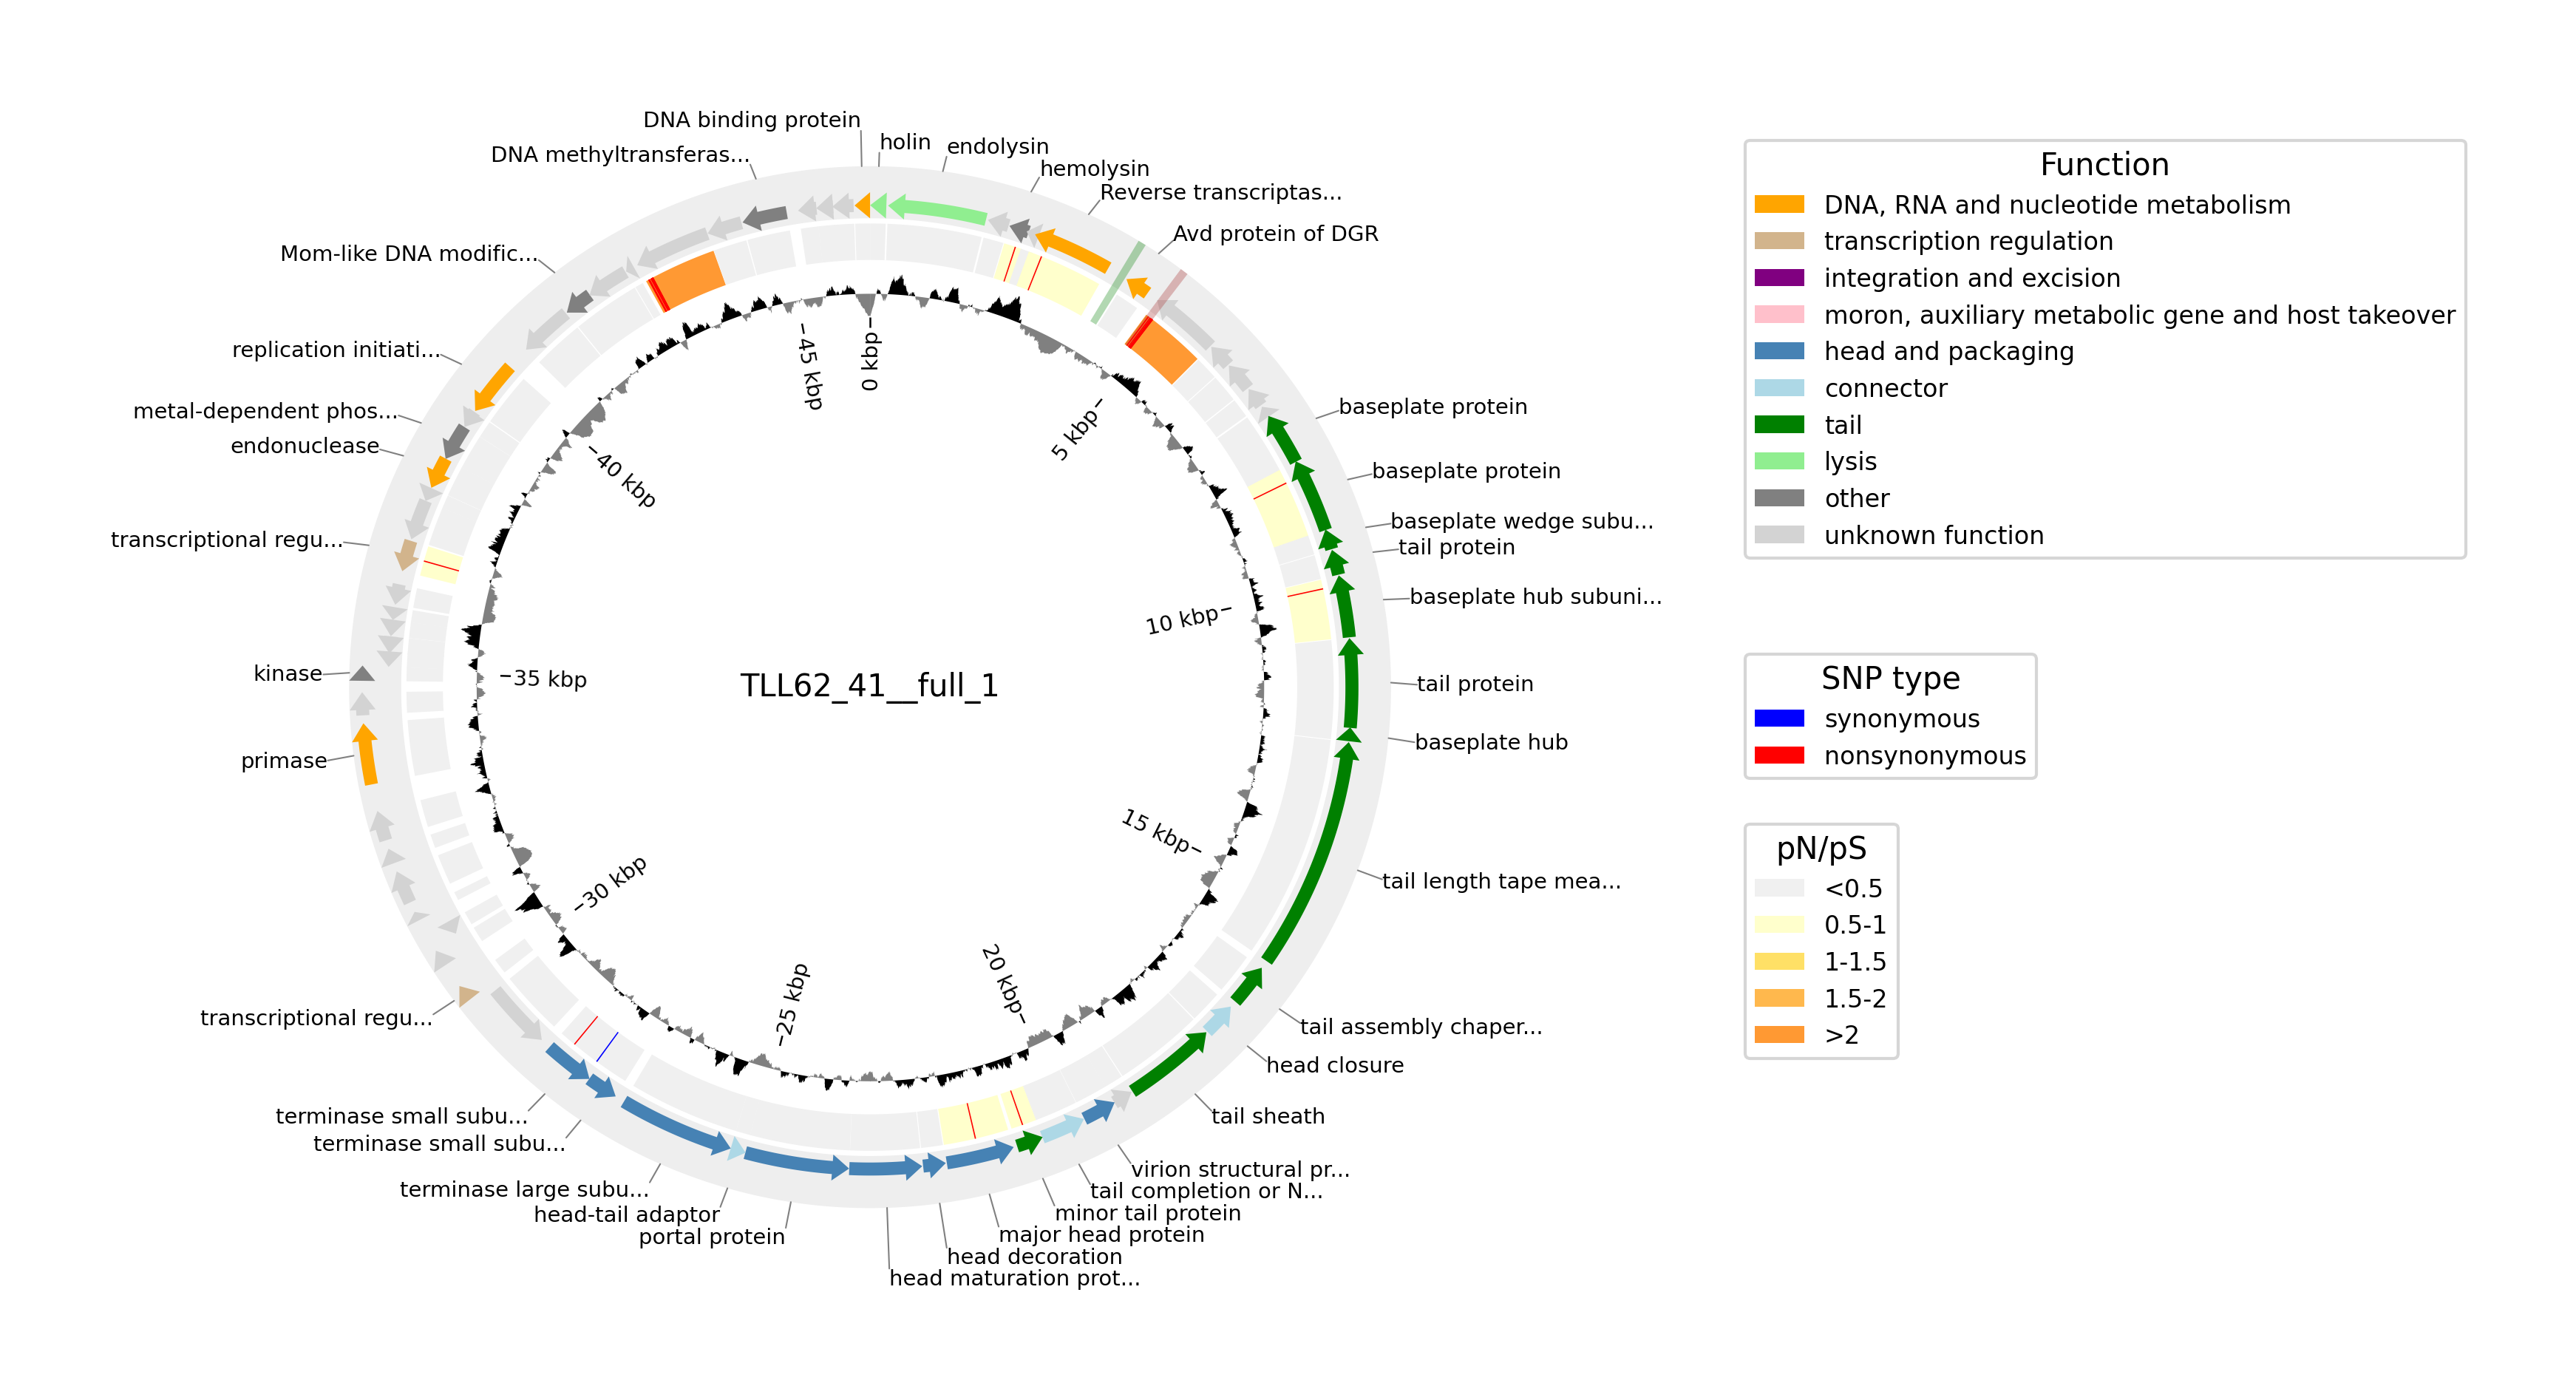

In [5]:
# ---------------------------
# Initialize Circos plot
# ---------------------------
gbk = Genbank(gbkfile)

seqid2size = gbk.get_seqid2size() # chromosome lengths
space = 0 if len(seqid2size) == 1 else 2 # space between chromosomes
circos = Circos(sectors=seqid2size, space=space)
circos.text(v.replace('provirus', '\nprovirus')) # for long virus names

# ---------------------------
# CDS track
# ---------------------------
seqid2features = gbk.get_seqid2features(feature_type="CDS")

for sector in circos.sectors:
    cds_track = sector.add_track((90, 100))
    cds_track.axis(fc="#EEEEEE", ec="none")

    features = seqid2features[sector.name]

    for feature in features:
        start, end = int(feature.location.start), int(feature.location.end)
        label = feature.qualifiers.get("product", [""])[0]

        # Extract gene ID from GenBank feature
        gid = feature.qualifiers.get("ID", [""])[0]

        # Get function, default to "unknown function"
        func = feature.qualifiers.get("function", ["unknown function"])[0].strip()
        color = function_colors.get(func, "lightgray")

        # Forward/reverse arrows
        if feature.location.strand == 1:
            cds_track.genomic_features(feature,
                                       plotstyle="arrow",
                                       r_lim=(95, 100),
                                       fc=color)
        else:
            cds_track.genomic_features(feature,
                                       plotstyle="arrow",
                                       r_lim=(90, 95),
                                       fc=color)

        # Determine annotation label
        if label and not label.startswith("hypothetical"):
            ann = label
        else:
            ann = None

        # If there is an annotation, draw it
        if ann:
            label_pos = (start + end) / 2
            cds_track.annotate(label_pos, ann, label_size=7)

# ---------------------------
# Coverage skew track
# ---------------------------
cov_track = sector.add_track((71, 81), r_pad_ratio=0.05) # with pN/pS track

# Create coverage table for all positions in genome
all_positions = pd.DataFrame({'POS': range(1, seqid2size[sector.name] + 1)})
df_cov = all_positions.merge(df_depth[['POS', s]], on='POS', how='left').fillna(0)

# Compute skew relative to median
median_cov = df_cov[s].median()
df_cov["skew"] = df_cov[s] - median_cov

# Extract the position and skew values
label_pos_list = df_cov["POS"].values
skew_values = df_cov["skew"].values

# Calculate the positive and negative skew components for the fill
positive_skew = np.where(skew_values > 0, skew_values, 0)
negative_skew = np.where(skew_values < 0, skew_values, 0)

# Set the limits for the color scale
vmin, vmax = np.min(skew_values), np.max(skew_values)

# Plot positive skew as a filled area above the median
cov_track.fill_between(
    label_pos_list, positive_skew, 0, vmin=vmin, vmax=vmax, color="black"
)

# Plot negative skew as a filled area below the median
cov_track.fill_between(
    label_pos_list, negative_skew, 0, vmin=vmin, vmax=vmax, color="grey"
)

# Add genome ticks inside this track
cov_track.xticks_by_interval(
    interval=5000,
    outer=False,
    label_formatter=lambda v: f"{v/1000:.0f} kbp",
    label_orientation="vertical",
    line_kws=dict(ec="black", lw=0.6),
    label_size=7
)

# ---------------------------
# pN/pS track
# ---------------------------
pnps_track = sector.add_track((82, 89), r_pad_ratio=0.05)

for _, row in df_pnps_v.iterrows():
    start, end, p = row["start"], row["end"], row["pNpS"]

    # Assign color based on pN/pS value
    color = get_pnps_color(p, pnps_colors)

    # Create fake SeqFeature for this gene
    fake_feature = SeqFeature(FeatureLocation(start, end))

    # Plot as a rectangle (forward strand)
    pnps_track.genomic_features(fake_feature, fc=color, plotstyle="box", r_lim=(82, 89))

# ---------------------------
# DGR track
# ---------------------------
dgr_track = sector.add_track((82, 100), r_pad_ratio=0.05) # span both tracks

for _, row in df_dgr_v.iterrows():
    for col in dgr_colors:
        coords = row[col].split("-")
        start, end = int(coords[0]), int(coords[1])
        fake_feature = SeqFeature(FeatureLocation(start, end))

        dgr_track.genomic_features(
            fake_feature,
            fc=dgr_colors[col],
            plotstyle="box",
            r_lim=(82, 100),
            alpha=0.3
        )

# ---------------------------
# SNP track
# ---------------------------
snp_track = sector.add_track((82, 89), r_pad_ratio=0.05)

for _, row in df_snp_v.iterrows():
    pos = int(row["POS"])
    mut_type = row["mutation_type"]

    color = snp_colors.get(mut_type, "black")

    # Create a "fake feature" for a single position
    fake_feature = SeqFeature(FeatureLocation(pos, pos + 20))

    # Plot as a thin rectangle (vertical line)
    snp_track.genomic_features(
        fake_feature,
        fc=color,
        plotstyle="box",
        r_lim=(82, 89),
    )

# ---------------------------
# Plot Circos figure
# ---------------------------
fig = circos.plotfig(dpi=300)
fig.set_size_inches(11, 11)

# ---------------------------
# Add legend
# ---------------------------
cds_legend_elements = [
    Patch(facecolor=col, label=func)
    for func, col in function_colors.items()
]
pnps_legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in pnps_colors.items()
]
snp_legend_elements = [
    Patch(facecolor=color, label=format_snp_label(label))
    for label, color in snp_colors.items()
]

leg1 = plt.legend(
    handles=pnps_legend_elements,
    title="pN/pS",
    bbox_to_anchor=(1.3, 0.375),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)
plt.gca().add_artist(leg1)

leg3 = plt.legend(
    handles=snp_legend_elements,
    title="SNP type",
    bbox_to_anchor=(1.3, 0.53),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)
plt.gca().add_artist(leg3)

leg2 = plt.legend(
    handles=cds_legend_elements,
    title="Function",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)

fig.savefig(f"FigS29A_{v}-circos.png", dpi=400, bbox_inches='tight')

### Supplementary Fig. 29B: TLL75_opera_contig_6_provirus_3_83774 (VFC 4)
Note that the first 21kbp of the predicted vOTU (assembled in TLL75) was not part of the replicating virus (detected in TLL62).

In [6]:
v = 'TLL75_opera_contig_6_provirus_3_83774'
s = 'TLL62'

gbkfile = f'../data/genome_annotations/{v}-pharokka.gbk'
df_depth = pd.read_csv(f'../data/genome_annotations/{v}-{s}-depth.tsv', sep='\t')
df_snp_v = df_snp[(df_snp.CHROM == v) & (df_snp.sample_id == s)]
df_pnps_v = df_pnps[(df_pnps.CHROM == v) & (df_pnps.sample_id == s)].copy()
df_pnps_v[['start','end']] = df_pnps_v[['start','end']].astype(int)
df_dgr_v = df_dgr[df_dgr.votu_id == v]

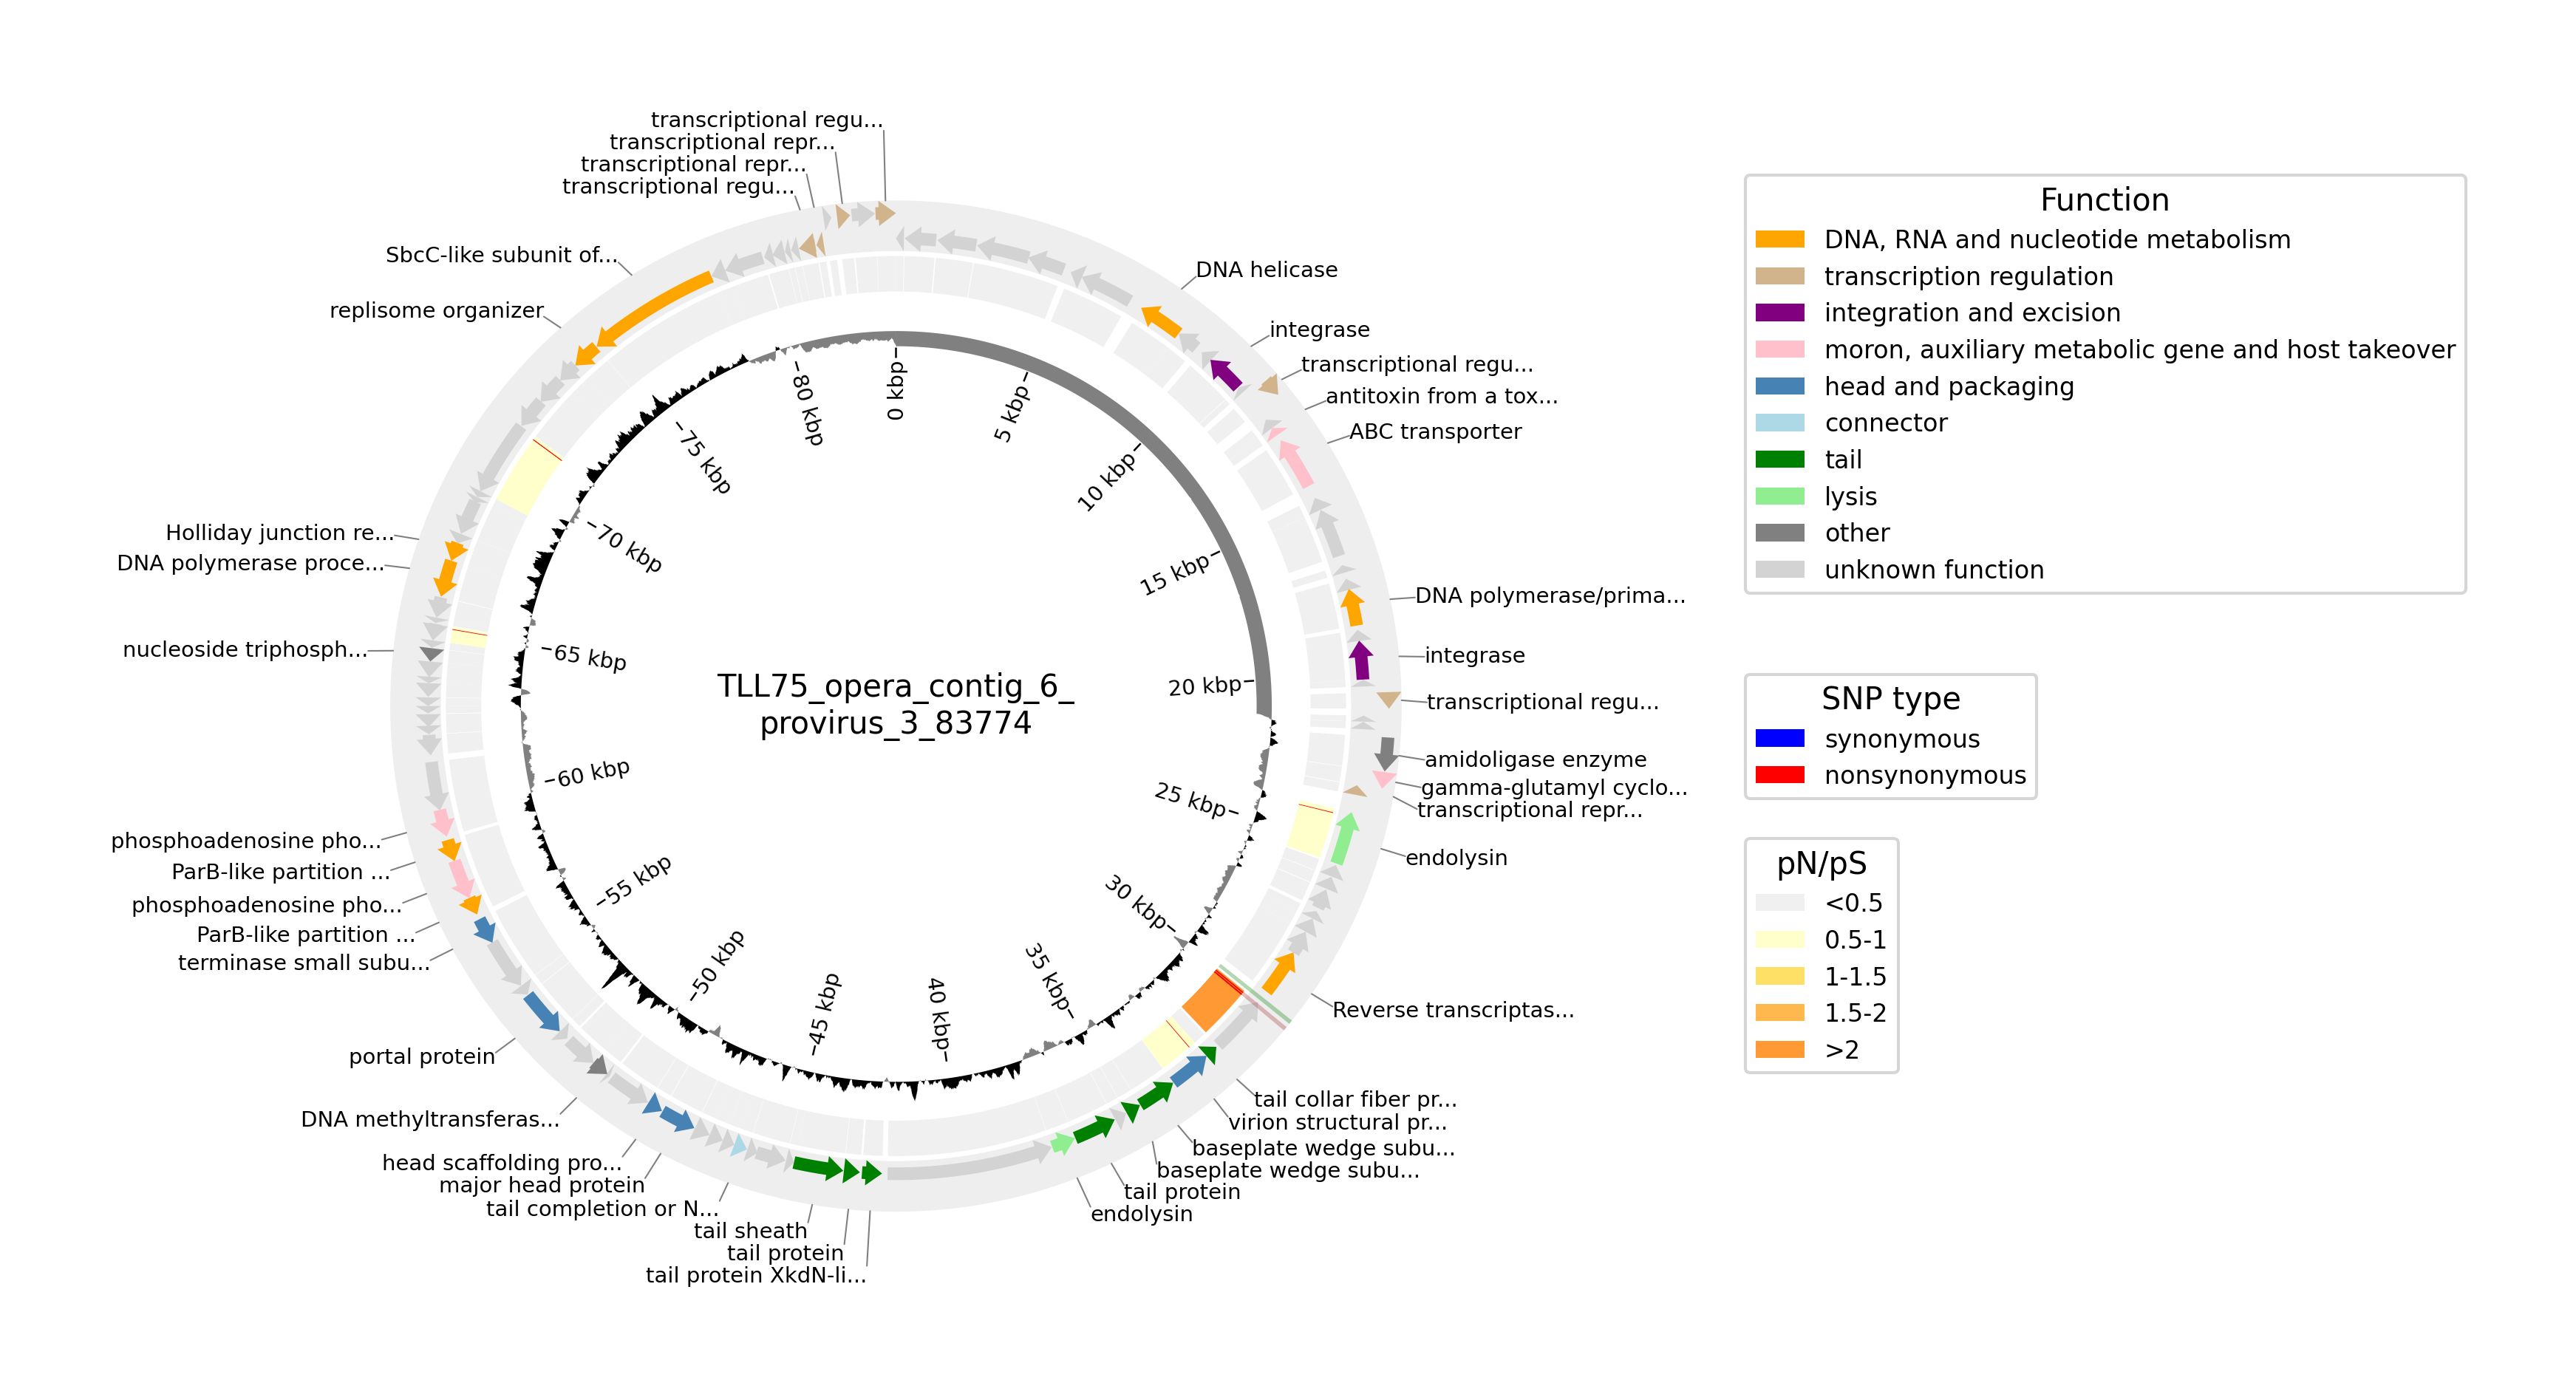

In [7]:
# ---------------------------
# Initialize Circos plot
# ---------------------------
gbk = Genbank(gbkfile)

seqid2size = gbk.get_seqid2size() # chromosome lengths
space = 0 if len(seqid2size) == 1 else 2 # space between chromosomes
circos = Circos(sectors=seqid2size, space=space)
circos.text(v.replace('provirus', '\nprovirus')) # for long virus names

# ---------------------------
# CDS track
# ---------------------------
seqid2features = gbk.get_seqid2features(feature_type="CDS")

for sector in circos.sectors:
    cds_track = sector.add_track((90, 100))
    cds_track.axis(fc="#EEEEEE", ec="none")

    features = seqid2features[sector.name]

    for feature in features:
        start, end = int(feature.location.start), int(feature.location.end)
        label = feature.qualifiers.get("product", [""])[0]

        # Extract gene ID from GenBank feature
        gid = feature.qualifiers.get("ID", [""])[0]

        # Get function, default to "unknown function"
        func = feature.qualifiers.get("function", ["unknown function"])[0].strip()
        color = function_colors.get(func, "lightgray")

        # Forward/reverse arrows
        if feature.location.strand == 1:
            cds_track.genomic_features(feature,
                                       plotstyle="arrow",
                                       r_lim=(95, 100),
                                       fc=color)
        else:
            cds_track.genomic_features(feature,
                                       plotstyle="arrow",
                                       r_lim=(90, 95),
                                       fc=color)

        # Determine annotation label
        if label and not label.startswith("hypothetical"):
            ann = label
        else:
            ann = None

        # If there is an annotation, draw it
        if ann:
            label_pos = (start + end) / 2
            cds_track.annotate(label_pos, ann, label_size=7)

# ---------------------------
# Coverage skew track
# ---------------------------
cov_track = sector.add_track((71, 81), r_pad_ratio=0.05) # with pN/pS track

# Create coverage table for all positions in genome
all_positions = pd.DataFrame({'POS': range(1, seqid2size[sector.name] + 1)})
df_cov = all_positions.merge(df_depth[['POS', s]], on='POS', how='left').fillna(0)

# Compute skew relative to median
median_cov = df_cov[s].median()
df_cov["skew"] = df_cov[s] - median_cov

# Extract the position and skew values
label_pos_list = df_cov["POS"].values
skew_values = df_cov["skew"].values

# Calculate the positive and negative skew components for the fill
positive_skew = np.where(skew_values > 0, skew_values, 0)
negative_skew = np.where(skew_values < 0, skew_values, 0)

# Set the limits for the color scale
vmin, vmax = np.min(skew_values), np.max(skew_values)

# Plot positive skew as a filled area above the median
cov_track.fill_between(
    label_pos_list, positive_skew, 0, vmin=vmin, vmax=vmax, color="black"
)

# Plot negative skew as a filled area below the median
cov_track.fill_between(
    label_pos_list, negative_skew, 0, vmin=vmin, vmax=vmax, color="grey"
)

# Add genome ticks inside this track
cov_track.xticks_by_interval(
    interval=5000,
    outer=False,
    label_formatter=lambda v: f"{v/1000:.0f} kbp",
    label_orientation="vertical",
    line_kws=dict(ec="black", lw=0.6),
    label_size=7
)

# ---------------------------
# pN/pS track
# ---------------------------
pnps_track = sector.add_track((82, 89), r_pad_ratio=0.05)

for _, row in df_pnps_v.iterrows():
    start, end, p = row["start"], row["end"], row["pNpS"]

    # Assign color based on pN/pS value
    color = get_pnps_color(p, pnps_colors)

    # Create fake SeqFeature for this gene
    fake_feature = SeqFeature(FeatureLocation(start, end))

    # Plot as a rectangle (forward strand)
    pnps_track.genomic_features(fake_feature, fc=color, plotstyle="box", r_lim=(82, 89))

# ---------------------------
# DGR track
# ---------------------------
dgr_track = sector.add_track((82, 100), r_pad_ratio=0.05) # span both tracks

for _, row in df_dgr_v.iterrows():
    for col in dgr_colors:
        coords = row[col].split("-")
        start, end = int(coords[0]), int(coords[1])
        fake_feature = SeqFeature(FeatureLocation(start, end))

        dgr_track.genomic_features(
            fake_feature,
            fc=dgr_colors[col],
            plotstyle="box",
            r_lim=(82, 100),
            alpha=0.3
        )

# ---------------------------
# SNP track
# ---------------------------
snp_track = sector.add_track((82, 89), r_pad_ratio=0.05)

for _, row in df_snp_v.iterrows():
    pos = int(row["POS"])
    mut_type = row["mutation_type"]

    color = snp_colors.get(mut_type, "black")

    # Create a "fake feature" for a single position
    fake_feature = SeqFeature(FeatureLocation(pos, pos + 20))

    # Plot as a thin rectangle (vertical line)
    snp_track.genomic_features(
        fake_feature,
        fc=color,
        plotstyle="box",
        r_lim=(82, 89),
    )

# ---------------------------
# Plot Circos figure
# ---------------------------
fig = circos.plotfig(dpi=300)
fig.set_size_inches(11, 11)

# ---------------------------
# Add legend
# ---------------------------
cds_legend_elements = [
    Patch(facecolor=col, label=func)
    for func, col in function_colors.items()
]
pnps_legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in pnps_colors.items()
]
snp_legend_elements = [
    Patch(facecolor=color, label=format_snp_label(label))
    for label, color in snp_colors.items()
]

leg1 = plt.legend(
    handles=pnps_legend_elements,
    title="pN/pS",
    bbox_to_anchor=(1.3, 0.375),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)
plt.gca().add_artist(leg1)

leg3 = plt.legend(
    handles=snp_legend_elements,
    title="SNP type",
    bbox_to_anchor=(1.3, 0.53),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)
plt.gca().add_artist(leg3)

leg2 = plt.legend(
    handles=cds_legend_elements,
    title="Function",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)

fig.savefig(f"FigS29B_{v}-circos.png", dpi=400, bbox_inches='tight')

### Supplementary Fig. 32: TLL102_opera_contig_232 (VFC 1)

In [8]:
v = 'TLL102_opera_contig_232'
s = 'TLL102'

gbkfile = f'../data/genome_annotations/{v}-pharokka.gbk'
df_depth = pd.read_csv(f'../data/genome_annotations/{v}-{s}-depth.tsv', sep='\t')

# DefenseFinder genes
df_def_v = pd.read_csv(f'../data/genome_annotations/{v}-defense_finder_genes.tsv', sep='\t')

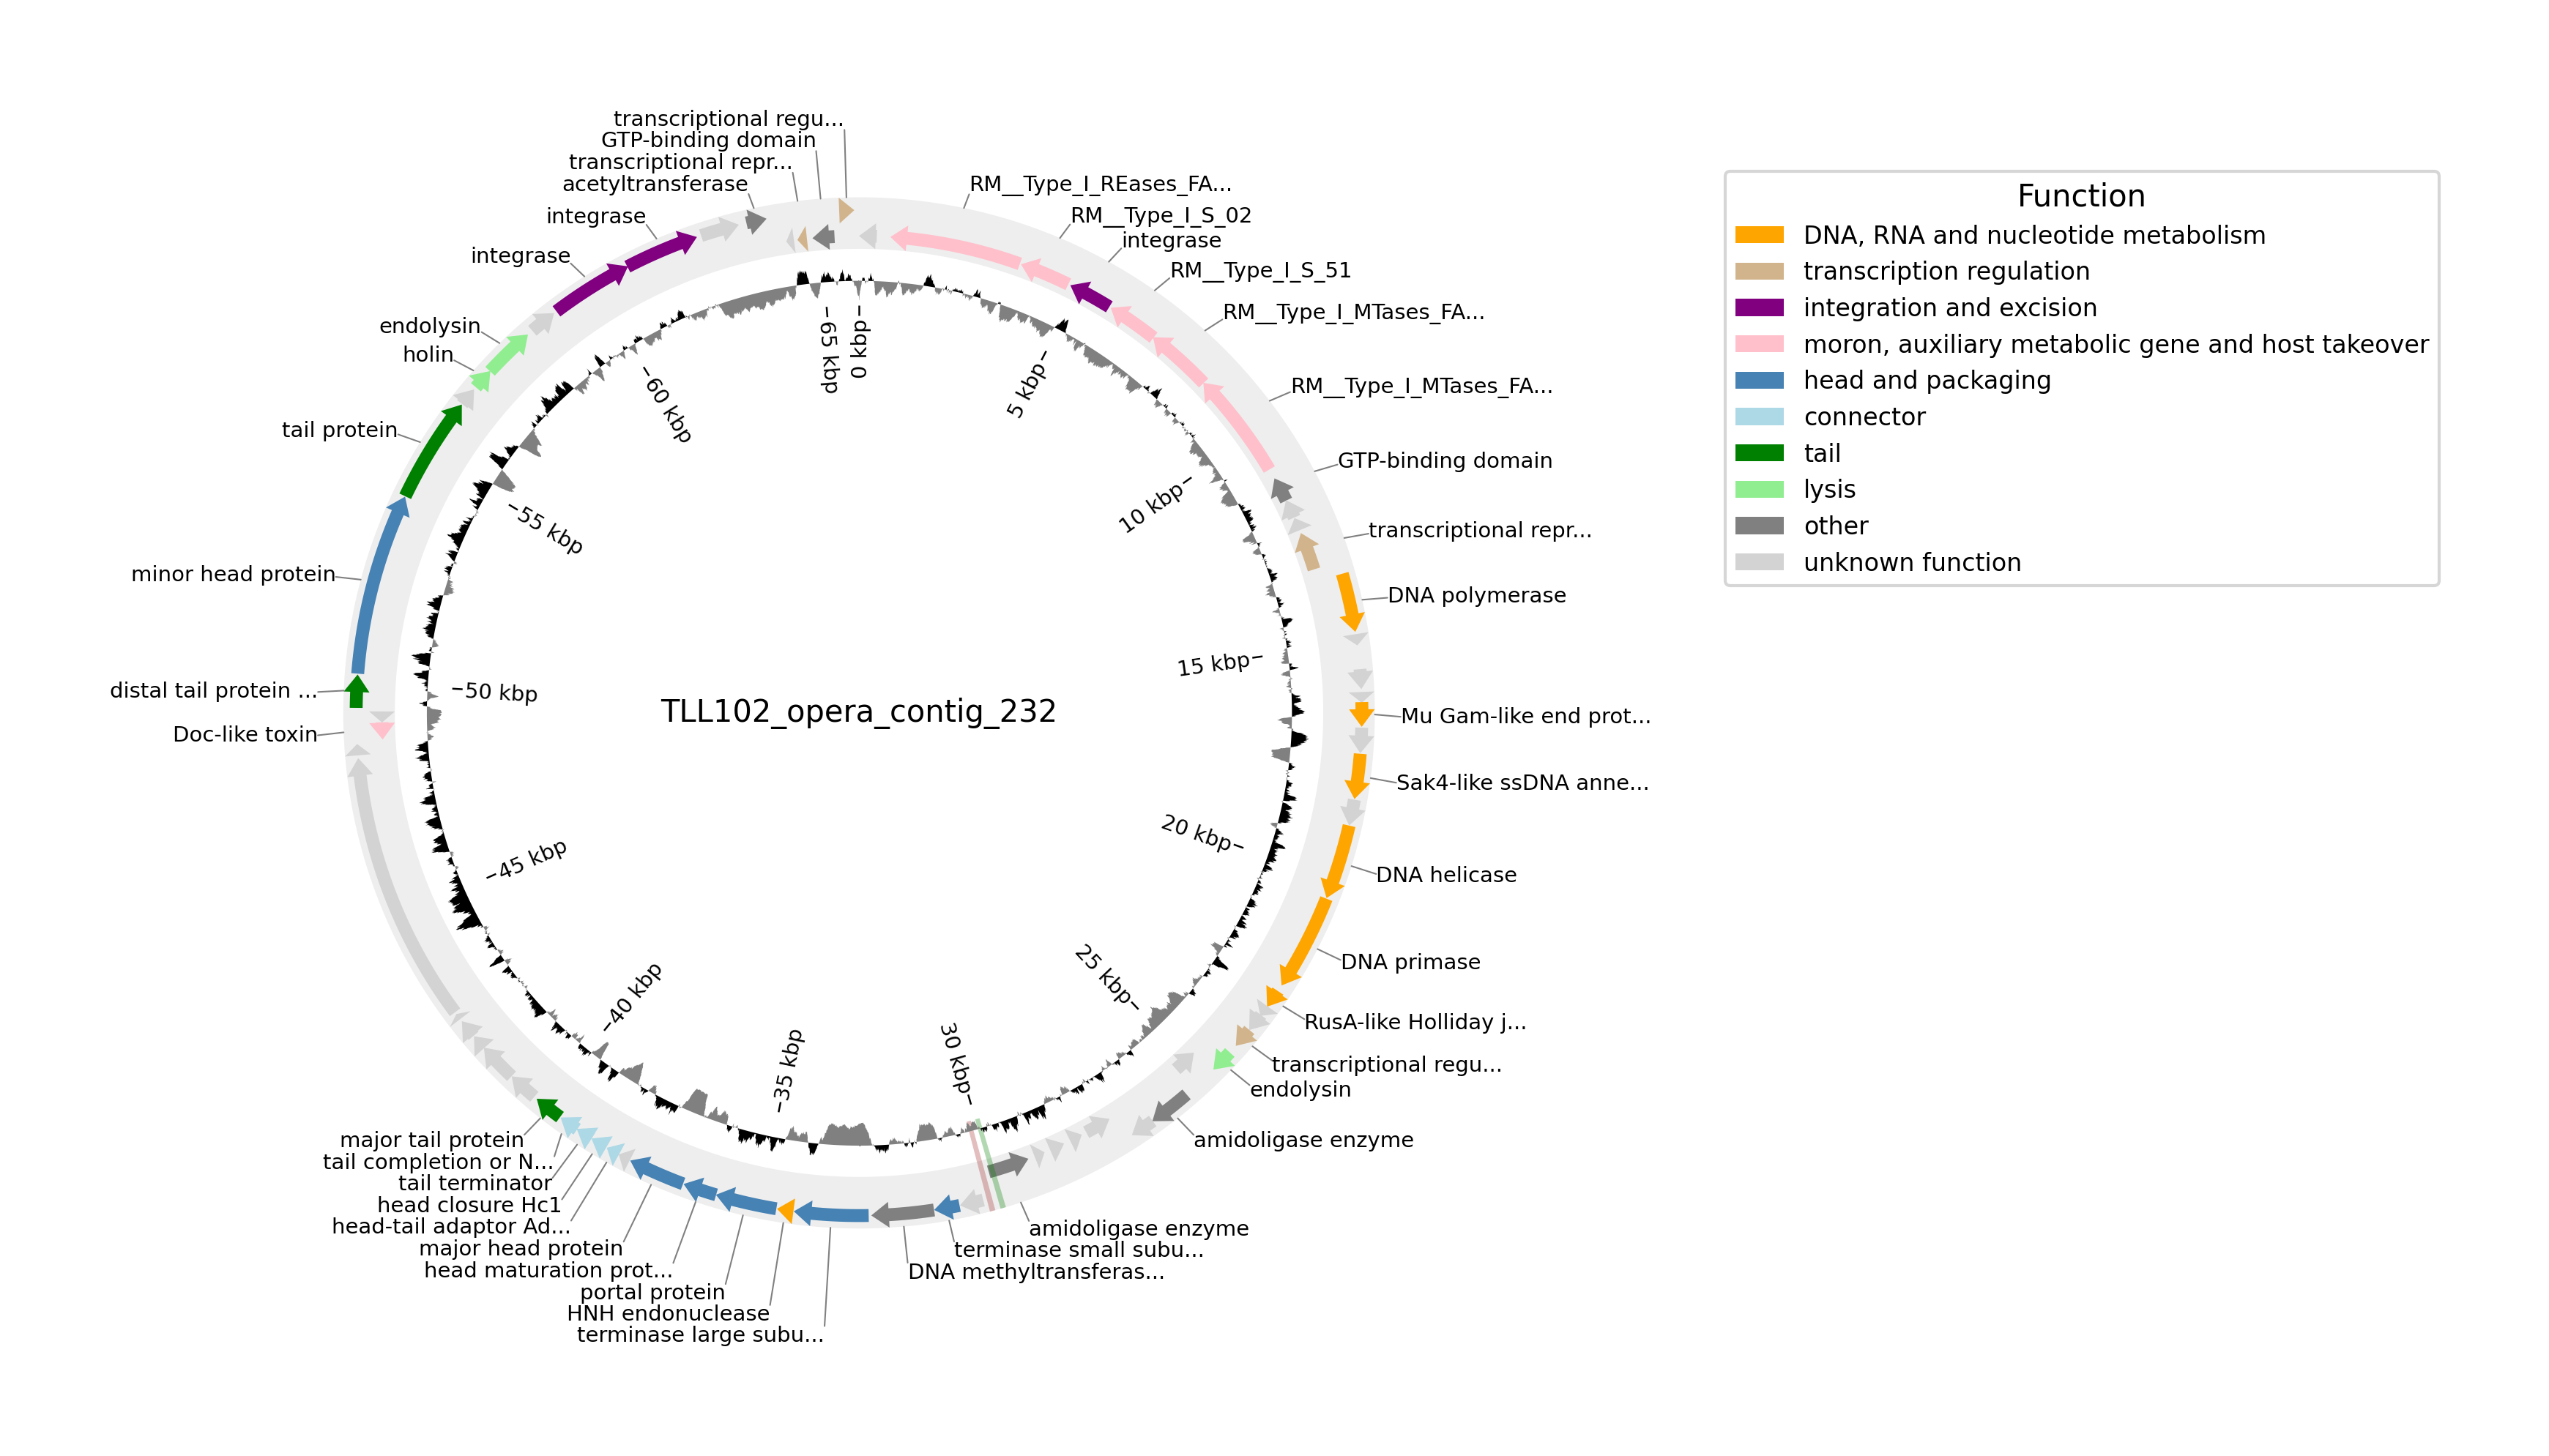

In [9]:
# ---------------------------
# Initialize Circos plot
# ---------------------------
gbk = Genbank(gbkfile)

seqid2size = gbk.get_seqid2size() # chromosome lengths
space = 0 if len(seqid2size) == 1 else 2 # space between chromosomes
circos = Circos(sectors=seqid2size, space=space)
circos.text(v.replace('provirus', '\nprovirus')) # for long virus names

# ---------------------------
# CDS track
# ---------------------------
seqid2features = gbk.get_seqid2features(feature_type="CDS")

# DefenseFinder genes
def_dict = dict(zip(df_def_v["hit_id"], df_def_v["gene_name"]))

for sector in circos.sectors:
    cds_track = sector.add_track((90, 100))
    cds_track.axis(fc="#EEEEEE", ec="none")

    features = seqid2features[sector.name]

    for feature in features:
        start, end = int(feature.location.start), int(feature.location.end)
        label = feature.qualifiers.get("product", [""])[0]

        # Extract gene ID from GenBank feature
        gid = feature.qualifiers.get("ID", [""])[0]

        # Get function, default to "unknown function"; annotate defense genes
        if gid in def_dict:
            func = "moron, auxiliary metabolic gene and host takeover"
        else:
            func = feature.qualifiers.get("function", ["unknown function"])[0].strip()
        color = function_colors.get(func, "lightgray")

        # Forward/reverse arrows
        if feature.location.strand == 1:
            cds_track.genomic_features(feature,
                                       plotstyle="arrow",
                                       r_lim=(95, 100),
                                       fc=color)
        else:
            cds_track.genomic_features(feature,
                                       plotstyle="arrow",
                                       r_lim=(90, 95),
                                       fc=color)

        # Determine annotation label; annotate defense genes
        if gid in def_dict:
            ann = def_dict[gid]
        elif label and not label.startswith("hypothetical"):
            ann = label
        else:
            ann = None

        # If there is an annotation, draw it
        if ann:
            label_pos = (start + end) / 2
            cds_track.annotate(label_pos, ann, label_size=7)

# ---------------------------
# Coverage skew track
# ---------------------------
cov_track = sector.add_track((79, 89), r_pad_ratio=0.05) # no pN/pS track

# Create coverage table for all positions in genome
all_positions = pd.DataFrame({'POS': range(1, seqid2size[sector.name] + 1)})
df_cov = all_positions.merge(df_depth[['POS', s]], on='POS', how='left').fillna(0)

# Compute skew relative to median
median_cov = df_cov[s].median()
df_cov["skew"] = df_cov[s] - median_cov

# Extract the position and skew values
label_pos_list = df_cov["POS"].values
skew_values = df_cov["skew"].values

# Calculate the positive and negative skew components for the fill
positive_skew = np.where(skew_values > 0, skew_values, 0)
negative_skew = np.where(skew_values < 0, skew_values, 0)

# Set the limits for the color scale
vmin, vmax = np.min(skew_values), np.max(skew_values)

# Plot positive skew as a filled area above the median
cov_track.fill_between(
    label_pos_list, positive_skew, 0, vmin=vmin, vmax=vmax, color="black"
)

# Plot negative skew as a filled area below the median
cov_track.fill_between(
    label_pos_list, negative_skew, 0, vmin=vmin, vmax=vmax, color="grey"
)

# Add genome ticks inside this track
cov_track.xticks_by_interval(
    interval=5000,
    outer=False,
    label_formatter=lambda v: f"{v/1000:.0f} kbp",
    label_orientation="vertical",
    line_kws=dict(ec="black", lw=0.6),
    label_size=7
)

# ---------------------------
# DGR track
# ---------------------------
dgr_track = sector.add_track((82, 100), r_pad_ratio=0.05) # span both tracks

for _, row in df_dgr_v.iterrows():
    for col in dgr_colors:
        coords = row[col].split("-")
        start, end = int(coords[0]), int(coords[1])
        fake_feature = SeqFeature(FeatureLocation(start, end))

        dgr_track.genomic_features(
            fake_feature,
            fc=dgr_colors[col],
            plotstyle="box",
            r_lim=(82, 100),
            alpha=0.3
        )

# ---------------------------
# Plot Circos figure
# ---------------------------
fig = circos.plotfig(dpi=300)
fig.set_size_inches(11, 11)

# ---------------------------
# Add legend
# ---------------------------
cds_legend_elements = [
    Patch(facecolor=col, label=func)
    for func, col in function_colors.items()
]

leg2 = plt.legend(
    handles=cds_legend_elements,
    title="Function",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)

fig.savefig(f"FigS32_{v}-circos.png", dpi=400, bbox_inches='tight')